In [262]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
pd.set_option('display.max_columns', None)

In [231]:
df = pd.read_csv("../../datasets/originals/videogame_requirements.csv")

In [232]:
df.head()

,Name,Min_CPU_CPU_Speed,Min_CPU_Turbo_Speed,Min_CPU_Physical_Cores,Min_CPU_Threads,Min_CPU_TDP,Min_CPU_Lithography,Min_CPU_Bit_Width,Min_CPU_Max_Temp,Min_CPU_Memory Channel,Min_CPU_Maximum Memory,Min_CPU_L1_Cache,Min_CPU_L2_Cache,Min_CPU_L3_Cache,Min_CPU_GD_Rating,Min_CPU_Release_Price,Recom_CPU_CPU_Speed,Recom_CPU_Turbo_Speed,Recom_CPU_Physical_Cores,Recom_CPU_Threads,Recom_CPU_TDP,Recom_CPU_Lithography,Recom_CPU_Bit_Width,Recom_CPU_Max_Temp,Recom_CPU_Memory Channel,Recom_CPU_Maximum Memory,Recom_CPU_L1_Cache,Recom_CPU_L2_Cache,Recom_CPU_L3_Cache,Recom_CPU_GD_Rating,Recom_CPU_Release_Price,Min_GPU_Process,Min_GPU_TMUs,Min_GPU_Texture_Rate,Min_GPU_ROPs,Min_GPU_Pixel_Rate,Min_GPU_Tensor_Cores,Min_GPU_Release_Price,Min_GPU_Direct_X,Min_GPU_Shader,Min_GPU_Open_GL,Min_GPU_Resolution,Min_GPU_Memory,Min_GPU_Memory_Speed,Min_GPU_Memory_Type,Min_GPU_Memory_Bandwidth,Min_GPU_DVI_Connection,Min_GPU_HDMI_Connection,Min_GPU_DisplayPort_Connection,Min_GPU_Boost_Clock,Min_GPU_PSU,Min_GPU_Power_Connector,Min_GPU_Best_RAM_Match,Min_GPU_Best_Resolution,Min_GPU_GD_RATING,Recom_GPU_Process,Recom_GPU_TMUs,Recom_GPU_Texture_Rate,Recom_GPU_ROPs,Recom_GPU_Pixel_Rate,Recom_GPU_Tensor_Cores,Recom_GPU_Release_Price,Recom_GPU_Direct_X,Recom_GPU_Shader,Recom_GPU_Open_GL,Recom_GPU_Resolution,Recom_GPU_Memory,Recom_GPU_Memory_Speed,Recom_GPU_Memory_Type,Recom_GPU_Memory_Bandwidth,Recom_GPU_DVI_Connection,Recom_GPU_HDMI_Connection,Recom_GPU_DisplayPort_Connection,Recom_GPU_Boost_Clock,Recom_GPU_PSU,Recom_GPU_Power_Connector,Recom_GPU_Best_RAM_Match,Recom_GPU_Best_Resolution,Recom_GPU_GD_RATING,Min_RAM,Recom_RAM,Min_VRAM,Recom_VRAM,Min_OS,Recom_OS,Min_Direct_X,Recom_Direct_X,Min_HDD_Space,Recom_HDD_Space,Release_Date
0,Zoo Tycoon 2: Zookeeper Collection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0.0,0.0,0,0,2006-10-17
1,Zoo Tycoon 2: Marine Mania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0.0,0.0,0,0,2006-10-17
2,Zoo Tycoon 2: Endangered Species,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0.0,0.0,0,0,2005-10-18
3,Zu Online,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0.0,0.0,0,0,2007-12-14
4,Adventure Quest Worlds,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0.0,0.0,0,0,2008-06-02


In [233]:
df = df.drop(columns=['Release_Date', 'Min_OS', 'Recom_OS'])

In [234]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10849 entries, 0 to 10848
Data columns (total 87 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Name                              10849 non-null  str    
 1   Min_CPU_CPU_Speed                 9277 non-null   float64
 2   Min_CPU_Turbo_Speed               9277 non-null   float64
 3   Min_CPU_Physical_Cores            9277 non-null   float64
 4   Min_CPU_Threads                   9277 non-null   float64
 5   Min_CPU_TDP                       9277 non-null   float64
 6   Min_CPU_Lithography               9277 non-null   float64
 7   Min_CPU_Bit_Width                 9277 non-null   float64
 8   Min_CPU_Max_Temp                  9277 non-null   float64
 9   Min_CPU_Memory Channel            9277 non-null   float64
 10  Min_CPU_Maximum Memory            9277 non-null   float64
 11  Min_CPU_L1_Cache                  9277 non-null   float64
 12  Min_CPU_L2_Cach

In [240]:
df.iloc[10848:]

,Min_CPU_CPU_Speed,Min_CPU_Turbo_Speed,Min_CPU_Physical_Cores,Min_CPU_Physical_Cores,Min_CPU_TDP,Min_CPU_L1_Cache,Min_CPU_L2_Cache,Min_CPU_L3_Cache,Recom_CPU_CPU_Speed,Recom_CPU_Turbo_Speed,Recom_CPU_Physical_Cores,Recom_CPU_Threads,Recom_CPU_L1_Cache,Recom_CPU_L2_Cache,Recom_CPU_L3_Cache,Min_GPU_Memory,Min_GPU_Memory_Speed,Recom_GPU_Memory,Recom_GPU_Memory_Speed,Min_RAM,Recom_RAM,Min_VRAM,Recom_VRAM
10848,3.4,3.85,6.0,6.0,110.0,320.0,4608.0,7.0,3.6,3.9,5.0,10.0,384.0,2560.0,12.0,2048.0,1564.0,8192.0,1251.0,8,16,2,8


In [241]:
df.dtypes

Min_CPU_CPU_Speed           float64
Min_CPU_Turbo_Speed         float64
Min_CPU_Physical_Cores      float64
Min_CPU_Physical_Cores      float64
Min_CPU_TDP                 float64
Min_CPU_L1_Cache            float64
Min_CPU_L2_Cache            float64
Min_CPU_L3_Cache            float64
Recom_CPU_CPU_Speed         float64
Recom_CPU_Turbo_Speed       float64
Recom_CPU_Physical_Cores    float64
Recom_CPU_Threads           float64
Recom_CPU_L1_Cache          float64
Recom_CPU_L2_Cache          float64
Recom_CPU_L3_Cache          float64
Min_GPU_Memory              float64
Min_GPU_Memory_Speed        float64
Recom_GPU_Memory            float64
Recom_GPU_Memory_Speed      float64
Min_RAM                       int64
Recom_RAM                     int64
Min_VRAM                      int64
Recom_VRAM                    int64
dtype: object

In [237]:
df = df[['Min_CPU_CPU_Speed', 'Min_CPU_Turbo_Speed', 'Min_CPU_Physical_Cores', 'Min_CPU_Physical_Cores', 'Min_CPU_TDP', 'Min_CPU_L1_Cache', \
'Min_CPU_L2_Cache', 'Min_CPU_L3_Cache', 'Recom_CPU_CPU_Speed', 'Recom_CPU_Turbo_Speed', 'Recom_CPU_Physical_Cores', 'Recom_CPU_Threads', \
'Recom_CPU_L1_Cache', 'Recom_CPU_L2_Cache', 'Recom_CPU_L3_Cache', 'Min_GPU_Memory', 'Min_GPU_Memory_Speed', 'Recom_GPU_Memory', \
'Recom_GPU_Memory_Speed', 'Min_RAM', 'Recom_RAM', 'Min_VRAM', 'Recom_VRAM']]

In [238]:
def convert_to_gb(value):
    if pd.isna(value):
        return value
        
    value = str(value).upper() 
    
    if 'GB' in value:
        return float(value.replace('GB', ''))
    elif 'MB' in value:
        return float(value.replace('MB', '')) / 1024.0
    else:
        return float(value)

In [239]:
for column in df.select_dtypes(include='str'):
    df[column] = df[column].apply(convert_to_gb)
    df[column] = df[column].round().astype(int)

In [242]:
df = df.dropna()

In [243]:
df['Min_VRAM'].unique()

array([0, 2, 1, 3, 4, 6, 8, 5])

In [276]:
data = df.to_numpy()

In [277]:
data

array([[ 1.7 ,  0.  ,  1.5 , ...,  2.  ,  0.  ,  0.  ],
       [ 1.63,  0.  ,  1.  , ...,  2.  ,  0.  ,  0.  ],
       [ 1.63,  0.  ,  1.  , ...,  2.  ,  0.  ,  0.  ],
       ...,
       [ 3.2 ,  3.65,  4.  , ...,  8.  ,  2.  ,  6.  ],
       [ 3.7 ,  4.  ,  6.  , ..., 16.  ,  6.  ,  0.  ],
       [ 3.4 ,  3.85,  6.  , ..., 16.  ,  2.  ,  8.  ]], shape=(7294, 23))

In [278]:
y_pred = KMeans(n_clusters=4, verbose=3, random_state=123).fit_predict(data)

Initialization complete
Iteration 0, inertia 34800880919.44861.
Iteration 1, inertia 25304396129.439083.
Iteration 2, inertia 24215018081.185474.
Iteration 3, inertia 23965264098.30772.
Iteration 4, inertia 23789407861.130917.
Iteration 5, inertia 23715427246.49404.
Iteration 6, inertia 23677535009.384575.
Iteration 7, inertia 23658246098.358013.
Iteration 8, inertia 23648751635.274586.
Iteration 9, inertia 23644955438.50745.
Iteration 10, inertia 23644005082.552296.
Iteration 11, inertia 23643897907.435997.
Converged at iteration 11: center shift 17.480420746044018 within tolerance 46.778528504610286.


In [279]:
data[:, 22]

array([0., 0., 0., ..., 6., 0., 8.], shape=(7294,))

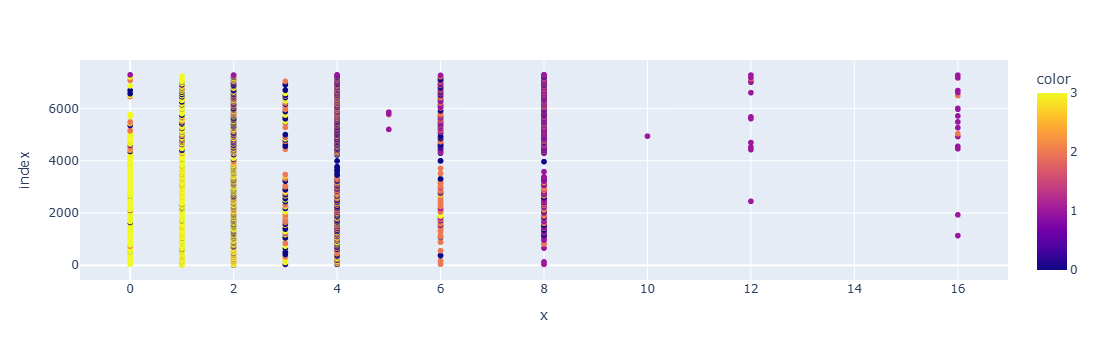

In [281]:
px.scatter(data[:, 19], data[:, 19], color=y_pred)